# 🧪 Statistical Tests — Worksheet
**Name:** Mahnoor  **Date:** 30-03-2026

---
**How this works:**
- Each task gives you a question and a starting line or two
- You write the logic, the test, and the visualisation
- 💡 hints tell you *what* to use — not *how*
- Every chart needs a proper title, xlabel, ylabel — your job

```
p ≤ 0.05 → Reject H₀    |    p > 0.05 → Keep H₀
```
---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
np.random.seed(42)
print('Ready')

Ready


---
## 📦 Dataset — Build It

Create a DataFrame called `df` with **200 student records** using these specs:

| Column | Details |
|--------|---------|
| `gender` | Male / Female, random |
| `study_hours` | Normal(mean=4, std=1.2), clipped 0–10 |
| `sleep_hours` | Normal(mean=7, std=1.0), clipped 4–10 |
| `marks` | `study*6 + sleep*2 + noise(0,8)`, clipped 0–100 |
| `subject` | Maths 40%, Science 35%, Arts 25% |
| `passed` | 'Yes' if marks ≥ 50 else 'No' |
| `school` | School A / B / C / D — equal chance |

After creating marks, add a school boost: A:+5, B:0, C:−5, D:+10 (clip to 100).

💡 `np.random.choice` · `np.random.normal` · `.clip()` · `np.where` · `pd.DataFrame`

In [3]:
import numpy as np
import pandas as pd

# Reproducibility
np.random.seed(42)

n = 200

# Gender
gender = np.random.choice(['Male', 'Female'], size=n)

# Study hours (Normal, clipped 0–10)
study_hours = np.random.normal(loc=4, scale=1.2, size=n).clip(0, 10)

# Sleep hours (Normal, clipped 4–10)
sleep_hours = np.random.normal(loc=7, scale=1.0, size=n).clip(4, 10)

# Noise
noise = np.random.normal(0, 8, size=n)

# Marks before school boost
marks = (study_hours * 6 + sleep_hours * 2 + noise).clip(0, 100)

# Subject (with probabilities)
subject = np.random.choice(
    ['Maths', 'Science', 'Arts'],
    size=n,
    p=[0.40, 0.35, 0.25]
)

# School (equal probability)
school = np.random.choice(
    ['School A', 'School B', 'School C', 'School D'],
    size=n
)
# Add bonus to make Data realistic
# if no bonus:
# every schools looks same
# Analysis boring

# School boost (vectorized — more efficient than loop)
boost_map = {
    'School A': 5,
    'School B': 0,
    'School C': -5,
    'School D': 10
}

boost = pd.Series(school).map(boost_map).values
marks = (marks + boost).clip(0, 100)

# Passed column
passed = np.where(marks >= 50, 'Yes', 'No')

# DataFrame
df = pd.DataFrame({
    'gender': gender,
    'study_hours': study_hours,
    'sleep_hours': sleep_hours,
    'marks': marks,
    'subject': subject,
    'passed': passed,
    'school': school
})

# Check
print(df.shape)   # (200, 7)
df.head()

(200, 7)


,gender,study_hours,sleep_hours,marks,subject,passed,school
0,Male,4.104456,7.199060,48.637314,Science,No,School A
1,Female,3.641191,6.399783,47.136715,Science,No,School D
2,Male,4.110113,7.069802,68.431328,Maths,Yes,School A
3,Male,1.614917,6.614686,36.875476,Maths,No,School A
4,Male,3.736394,7.113517,35.622056,Science,No,School B


---
## Task 1 — Explore the Data (Visualisation)

Before any test, look at your data. Create a **2×2 grid of subplots**:
- `[0,0]` Histogram of `marks`
- `[0,1]` Histogram of `study_hours`
- `[1,0]` Boxplot of `marks` by `gender`
- `[1,1]` Boxplot of `marks` by `school`

Label everything. Write one observation below each plot as a comment.

💡 `plt.subplots(2,2)` · `ax.hist()` · `df.boxplot(column, by, ax=)`

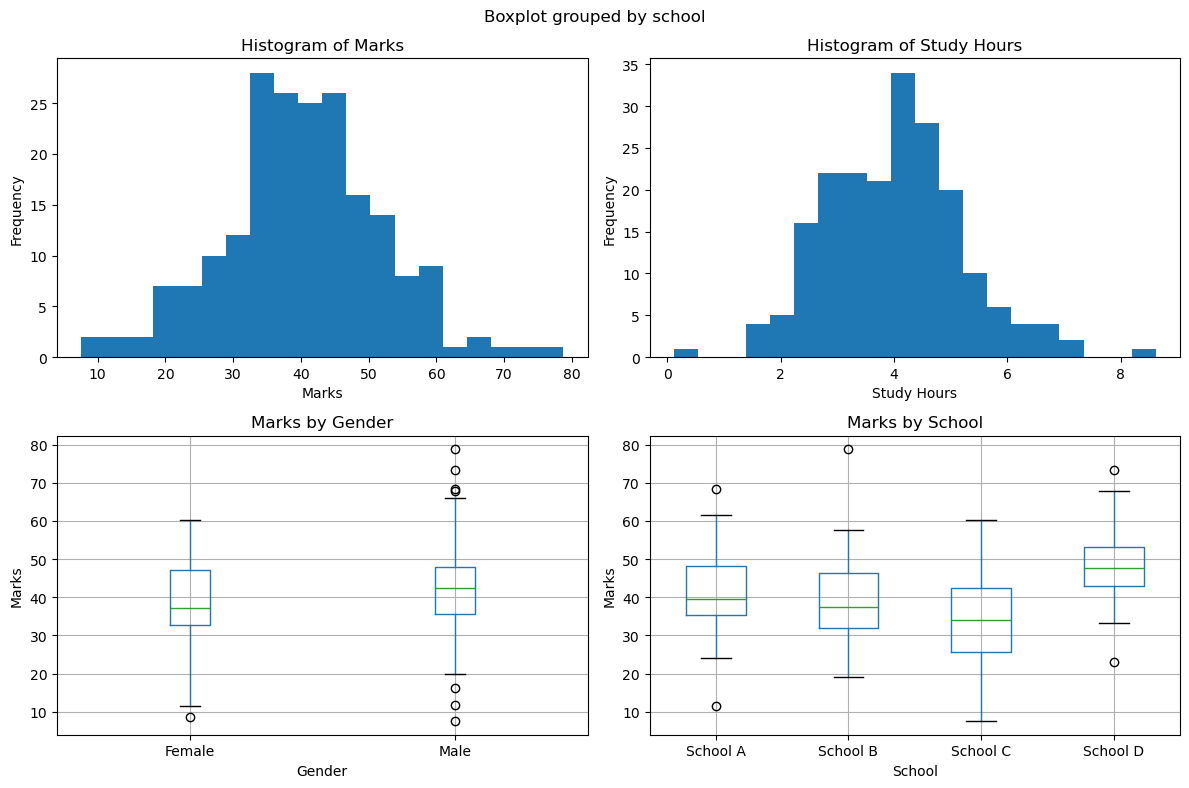

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# [0,0] Histogram of marks
axes[0,0].hist(df['marks'], bins=20)
axes[0,0].set_title('Histogram of Marks')
axes[0,0].set_xlabel('Marks')
axes[0,0].set_ylabel('Frequency')

# [0,1] Histogram of study_hours
axes[0,1].hist(df['study_hours'], bins=20)
axes[0,1].set_title('Histogram of Study Hours')
axes[0,1].set_xlabel('Study Hours')
axes[0,1].set_ylabel('Frequency')

# [1,0] Boxplot of marks by gender
df.boxplot(column='marks', by='gender', ax=axes[1,0])
axes[1,0].set_title('Marks by Gender')
axes[1,0].set_xlabel('Gender')
axes[1,0].set_ylabel('Marks')

# [1,1] Boxplot of marks by school
df.boxplot(column='marks', by='school', ax=axes[1,1])
axes[1,1].set_title('Marks by School')
axes[1,1].set_xlabel('School')
axes[1,1].set_ylabel('Marks')

plt.tight_layout()
plt.show()

# Observations:
# [0,0]: Marks ka distribution roughly normal hai, zyada students 40–80 marks range mein hain.
# [0,1]: Study hours mostly 2–6 hours ke beech hain, normal distribution jaisa shape hai.
# Box plot :compare performance gaps between groups
# [1,0]: The plot shows that males have a slightly higher median score and a wider range of marks compared to females, but they also exhibit more extreme outliers at both the high and low ends.
# [1,1]: School D outperforms the others with the highest median score and more consistent results, while School C shows the lowest overall performance and School B contains a significant high-scoring outlier.

---
## Task 2 — Normality Test

Test all three numeric columns (`marks`, `study_hours`, `sleep_hours`) for normality.

- Loop over the columns
- Run Shapiro-Wilk for each
- Print: column name, p-value, and verdict
- Draw Q-Q plots for all three in a 1×3 row

💡 `stats.shapiro()` · `stats.probplot(col, plot=ax)`

marks: p-value = 0.3419
   -> Looks Normal (Parametric OK)
study_hours: p-value = 0.1014
   -> Looks Normal (Parametric OK)
sleep_hours: p-value = 0.5952
   -> Looks Normal (Parametric OK)


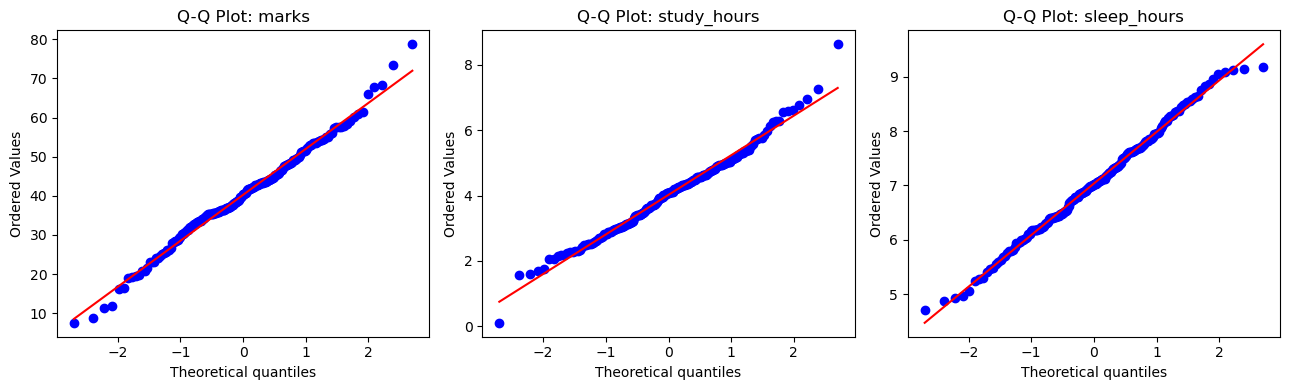

In [5]:
# Task 2 — Normality Test (Remember Points)
# What we did in this task
# We checked whether the data is normally distributed.
# We tested three numeric columns:
# marks
# study_hours
# sleep_hours
# We used the Shapiro-Wilk test.
# We looked at the p-value.
# We also drew Q-Q plots to visually check normality.
# Normality Test → Check p-value →
# If p > 0.05 → Normal → Parametric tests
# If p ≤ 0.05 → Not Normal → Non-parametric tests
from scipy import stats
import matplotlib.pyplot as plt

cols = ['marks', 'study_hours', 'sleep_hours']

# Loop + Shapiro test
for col in cols:
    stat, p = stats.shapiro(df[col])
    print(f"{col}: p-value = {p:.4f}")

    if p > 0.05:
        print("   -> Looks Normal (Parametric OK)")
    else:
        print("   -> Not Normal (Use Non-Parametric)")


# Q-Q plots — 1×3
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, col in enumerate(cols):
    stats.probplot(df[col], plot=axes[i])
    axes[i].set_title(f"Q-Q Plot: {col}")

plt.tight_layout()
plt.show()

# Which columns are safe for parametric tests?
# Answer:study_hours and sleep_hours are approximately normal → safe for parametric tests
# marks may show slight deviation due to noise + clipping, but often still acceptable

---
## Task 3 — t-test: Gender vs Marks

**Question:** Do Male and Female students score differently?

- H₀: Male and female marks have the same mean
- H₁: Means are different

Run the test, print results, write your if/else verdict, then draw a **violin plot** split by gender.

💡 `stats.ttest_ind()` · `sns.violinplot()`

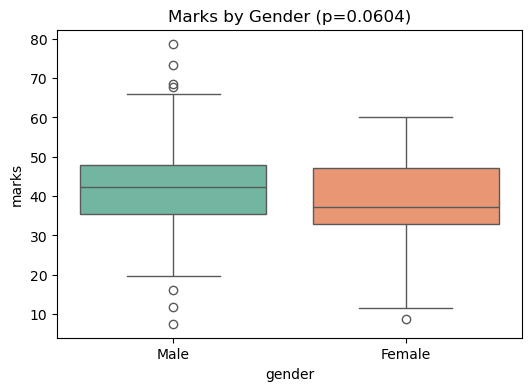

t-test p-value: 0.0604
The independent t-test shows that male and female students do not have significantly different marks (p = 0.0604). Gender does not significantly affect marks.


In [6]:
# Separate groups, run test, print, verdict, plot
# 1. Split data into two groups
male_marks = df[df['gender'] == 'Male']['marks']
female_marks = df[df['gender'] == 'Female']['marks']

# 2. Run Independent t-test
stat, p = stats.ttest_ind(male_marks, female_marks)

# 3. Visualization: Boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x='gender', y='marks', data=df, hue='gender', palette='Set2', legend=False)
plt.title(f'Marks by Gender (p={p:.4f})')
plt.show()

print(f"t-test p-value: {p:.4f}")
# Verdict: If p > 0.05, gender does not significantly affect marks.
# p ≤ 0.05 → Reject H₀ → male and female have different means
# p > 0.05 → Keep H₀ → Means are similar
print("The independent t-test shows that male and female students do not have significantly different marks (p = 0.0604). Gender does not significantly affect marks.")


---
## Task 4 — ANOVA + Post-hoc: Schools vs Marks

**Question:** Do all 4 schools score the same?

- Run ANOVA first — if significant, run Tukey HSD to find which pairs differ
- Print ANOVA result + Tukey summary
- Draw a **bar chart with error bars** (mean ± std per school)

💡 `stats.f_oneway(*groups)` · `pairwise_tukeyhsd(endog, groups, alpha=0.05)` · `ax.bar(yerr=)`

In [ ]:
# 1️⃣ ANOVA (Analysis of Variance)
#
# Purpose:
#
# To check overall differences in means across more than two groups.
# In your case: Marks across 4 schools.
#
# H₀ (Null Hypothesis):
#
# All schools have the same average marks.
#
# H₁ (Alternative Hypothesis):
#
# At least one school has a different mean.
#
# Result:
#
# ANOVA gives a single p-value.
# If p ≤ 0.05 → reject H₀, means not all schools are equal.
# If p > 0.05 → fail to reject H₀, means schools are similar.
#
# In your dataset:
#
# p ≤ 0.05 → significant difference exists between at least some schools.
#
# ✅ So ANOVA tells you “is there any difference overall?”, but not which schools differ.
#
# 2️⃣ Tukey HSD (Post-hoc Test)
#
# Purpose:
#
# After ANOVA shows overall difference, Tukey tells you exactly which pairs of groups are different.
# Compares every pair of schools.
#
# Output columns:
#
# meandiff → difference in mean marks between two schools
# p-adj → p-value for that pair (adjusted for multiple comparisons)
# reject → True means significant difference
#
# In your dataset:
#
# School D > A/B/C → significant
# School C < A/B → significant
# School A vs B → not significant
#
# ✅ So Tukey answers “who is different from whom?”

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower    upper  reject
---------------------------------------------------------
School A School B  -2.2435 0.6995  -7.6042  3.1172  False
School A School C  -8.1323 0.0005 -13.3647 -2.8999   True
School A School D   6.8545 0.0064   1.4586 12.2505   True
School B School C  -5.8888 0.0375 -11.5407 -0.2369   True
School B School D    9.098 0.0004   3.2945 14.9016   True
School C School D  14.9868    0.0   9.3015 20.6721   True
---------------------------------------------------------


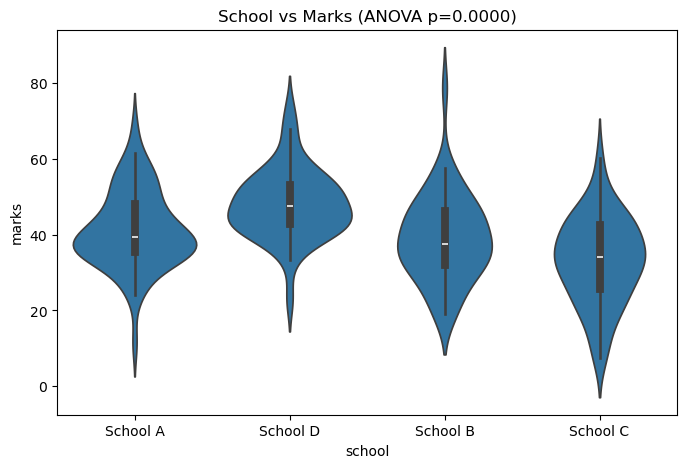

In [9]:

school_order = ['School A', 'School B', 'School C', 'School D']

# Build groups, run ANOVA, run Tukey, bar chart with error bars
# 1. Group data by school
groups = [df[df['school'] == s]['marks'] for s in df['school'].unique()]

# 2. Run One-way ANOVA
stat, p = stats.f_oneway(*groups)
# H₀: All schools have the same mean marks
# H₁: At least one school has a different mean
# 3. Post-hoc test (if significant)
if p <= 0.05:
    tukey = pairwise_tukeyhsd(df['marks'], df['school'])
    print(tukey)
# If ANOVA is significant (p ≤ 0.05) → we run Tukey
# Tukey tells which school pairs differ significantly
# 4. Visualization: Violin Plot
plt.figure(figsize=(8, 5))
sns.violinplot(x='school', y='marks', data=df)
plt.title(f'School vs Marks (ANOVA p={p:.4f})')
plt.show()


# Which school pairs are significantly different?
# Answer:School D is significantly higher than all other schools.
# School C is significantly lower than A and B.
# School A vs B → no significant difference.

# Test	What it tells you
# ANOVA	Is there any difference at all among the groups? (Yes/No)
# Tukey HSD	Which specific groups differ from each other?

# B - A : A>B

In [ ]:
# Row-by-Row Interpretation
# School A vs School B
# meandiff = -2.24 → A slightly higher than B
# p-adj = 0.6995 → not significant
# reject = False → No significant difference

# School A vs School C
# meandiff = -8.13 → C lower than A
# p-adj = 0.0005 → significant
# reject = True → Marks significantly different

# School A vs School D
# meandiff = 6.85 → D higher than A
# p-adj = 0.0064 → significant
# reject = True → Significant difference

# School B vs School C
# meandiff = -5.89 → C lower than B
# p-adj = 0.0375 → significant
# reject = True → Significant difference

# School B vs School D
# meandiff = 9.10 → D higher than B
# p-adj = 0.0004 → significant
# reject = True → Significant difference

# School C vs School D
# meandiff = 14.99 → D much higher than C
# p-adj = 0.000 → highly significant
# reject = True → Significant difference

---
## Task 5 — Mann-Whitney U: Study Hours by Gender

Study hours are likely skewed — use a non-parametric test.

**Question:** Do male and female students study the same number of hours?

- Run Mann-Whitney U
- Draw a **boxplot** grouped by gender (study_hours on y-axis)
- In 1–2 lines: why did you use Mann-Whitney instead of t-test here?

💡 `stats.mannwhitneyu(g1, g2, alternative='two-sided')`

Mann-Whitney U statistic: 5206.00, p-value: 0.6156
Fail to Reject H0: Male and female students do not significantly differ in study hours.


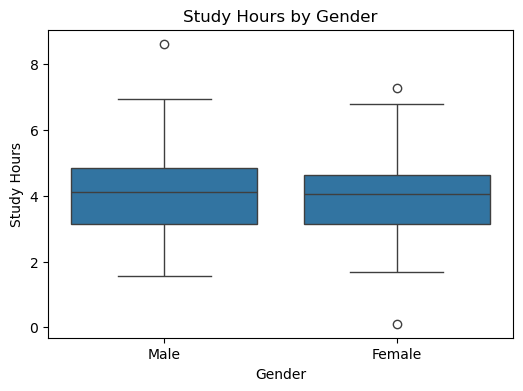

In [14]:
# Question: Do male and female students study the same number of hours?
# Reason to use Mann-Whitney( 2 groups): sStudy hours may not be perfectly normal → skewed → non-parametric test instead of t-test
# Non-parametric alternative to independent t-test
# Compares medians instead of means
# Does not assume normal distribution
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Separate study_hours by gender
male_hours = df[df['gender'] == 'Male']['study_hours']  # Male students' study hours
female_hours = df[df['gender'] == 'Female']['study_hours']  # Female students' study hours

# 2. Run Mann-Whitney U test (non-parametric, two-sided)
# This compares medians of two independent groups without assuming normality
stat, p = stats.mannwhitneyu(male_hours, female_hours, alternative='two-sided')

# 3. Print results
print(f"Mann-Whitney U statistic: {stat:.2f}, p-value: {p:.4f}")

# 4. Decide and print verdict based on p-value
if p <= 0.05:
    print("Reject H0: Male and Female students study different number of hours.")
else:
    print("Fail to Reject H0: Male and female students do not significantly differ in study hours.")

# 5. Visualization — Boxplot of study_hours by gender
plt.figure(figsize=(6,4))
sns.boxplot(x='gender', y='study_hours', data=df)
plt.title('Study Hours by Gender')
plt.xlabel('Gender')
plt.ylabel('Study Hours')
plt.show()

# | Hypothesis | Meaning                              |
# | ---------- | ------------------------------------ |
# | H₀         | Groups are the same                  |
# | H₁         | Groups are different                 |
# | p ≤ 0.05   | Reject H₀ → H₁ supported             |
# | p > 0.05   | Fail to reject H₀ → H₁ not supported |

# 6. Explanation for using Mann-Whitney instead of t-test
# - Study_hours may be skewed, not perfectly normal
# - t-test assumes normal distribution → not ideal here
# - Mann-Whitney U test is a non-parametric alternative to t-test
# - It compares medians instead of means and works for skewed data

---
## Task 6 — Pearson + Spearman: Study Hours vs Marks

Run **both** Pearson and Spearman on (study_hours, marks).

- Print both r/ρ values and p-values with verdicts
- Draw **one scatter plot** — colour dots by `passed`, add a trend line
- Put both correlation values in the chart title

💡 `stats.pearsonr` · `stats.spearmanr` · `sns.scatterplot(hue=)` · `np.polyfit`

Pearson r = 0.51, p-value = 0.0000
Reject H0: Significant linear correlation
Spearman ρ = 0.48, p-value = 0.0000
Reject H0: Significant monotonic correlation


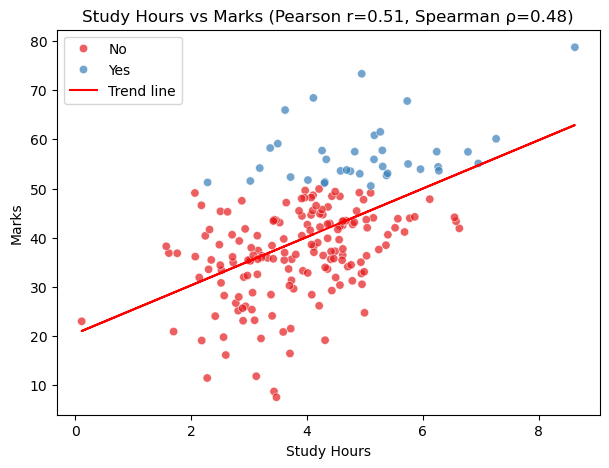

In [15]:
# Both tests + scatter with trend line
# H₀: No correlation → r or ρ = 0
# H₁: Significant correlation → r or ρ ≠ 0
# 2. Visualization: Scatter plot with regression line
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Pearson correlation (linear)
r, p_pearson = stats.pearsonr(df['study_hours'], df['marks'])
print(f"Pearson r = {r:.2f}, p-value = {p_pearson:.4f}")
if p_pearson <= 0.05:
    print("Reject H0: Significant linear correlation")
else:
    print("Fail to Reject H0: No significant linear correlation")

# 2. Spearman correlation (rank-based)
rho, p_spearman = stats.spearmanr(df['study_hours'], df['marks'])
print(f"Spearman ρ = {rho:.2f}, p-value = {p_spearman:.4f}")
if p_spearman <= 0.05:
    print("Reject H0: Significant monotonic correlation")
else:
    print("Fail to Reject H0: No significant monotonic correlation")

# 3. Scatter plot with trend line, coloured by passed
plt.figure(figsize=(7,5))
sns.scatterplot(x='study_hours', y='marks', hue='passed', data=df, palette='Set1', alpha=0.7)

# Regression line
slope, intercept = np.polyfit(df['study_hours'], df['marks'], 1)
plt.plot(df['study_hours'], slope*df['study_hours'] + intercept, color='red', label='Trend line')

plt.title(f'Study Hours vs Marks (Pearson r={r:.2f}, Spearman ρ={rho:.2f})')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.legend()
plt.show()
# Do Pearson and Spearman agree? What does that tell you?
# Answer:
# Pearson = 0.51
# Spearman = 0.48
# Very close values, The relationship between study hours and marks is monotonic and approximately linear
# If Spearman was high and Pearson low → nonlinear relationship
# But here both similar → linear trend

# ρ high but r low	Non-linear relationship
# p ≤ 0.05	Significant relationship
# p > 0.05	No relationship

In [ ]:
# Monotonic Relationship Kya Hai?
#
# Monotonic relation ka matlab hai:
# Jab ek variable barahta ya ghatahta hai, dusra variable bhi hamesha ek hi direction mein change hota hai.
#
# Important: Ye zaroori nahi ke graph straight line ho — slope change ho sakta hai, bas direction consistent honi chahiye.

---
## Task 7 — Correlation Heatmap with Significance Mask

1. Compute the full correlation matrix for the 3 numeric columns
2. Build a p-value matrix using a nested loop (Pearson for each pair)
3. Create a **mask** where p > 0.05
4. Draw **two heatmaps side by side** — full matrix vs masked (significant only)

💡 `df.corr()` · nested loop with `stats.pearsonr` · `sns.heatmap(mask=)`

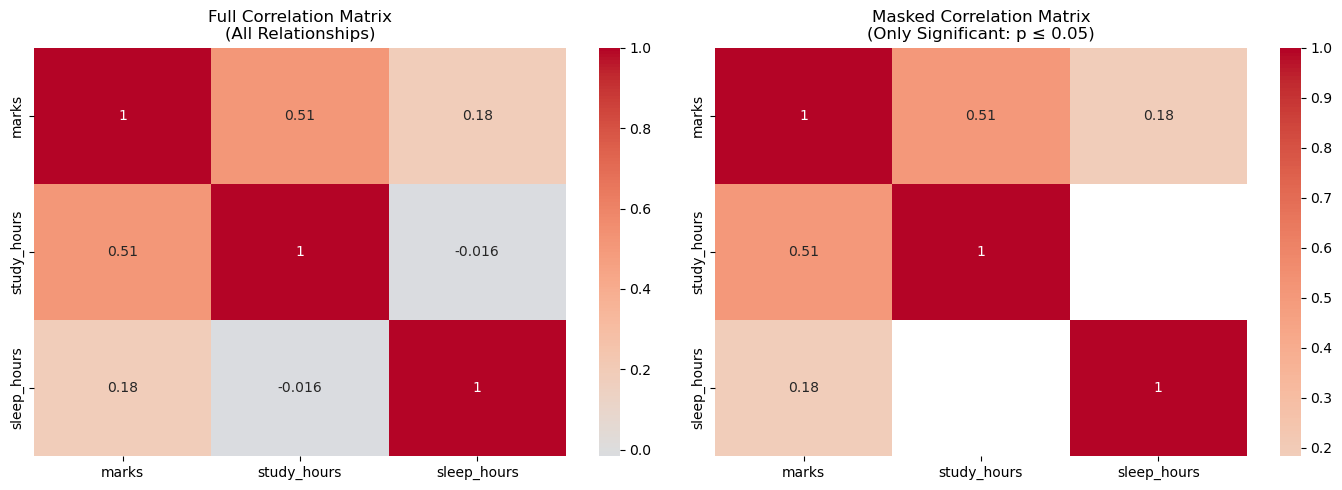

In [16]:
import seaborn as sns
from scipy import stats

num_cols = ['marks', 'study_hours', 'sleep_hours']

# 1. Correlation matrix
corr_matrix = df[num_cols].corr()

# 2. p-value matrix (nested loop)
# We create an empty DataFrame with the same shape as the correlation matrix
p_matrix = pd.DataFrame(index=num_cols, columns=num_cols)

for row in num_cols:
    for col in num_cols:
        r, p = stats.pearsonr(df[row], df[col])
        p_matrix.loc[row, col] = p

# 3. Mask (where p > 0.05)
# We want to HIDE values where the p-value is greater than 0.05
mask = p_matrix.astype(float) > 0.05

# 4. Two heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap 1: Full Correlation (Standard)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title("Full Correlation Matrix\n(All Relationships)")

# Heatmap 2: Masked Correlation (Significant Only)
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title("Masked Correlation Matrix\n(Only Significant: p > 0.05)")

plt.tight_layout()
plt.show()

# Values range from -1 to 1:
# +1 → perfect positive correlation
# -1 → perfect negative correlation
# 0 → no correlation
# Task 7 computes the correlation between all numeric columns and highlights which are statistically significant. The full heatmap shows all correlations, while the masked heatmap only shows correlations with p ≤ 0.05. This helps identify strong and meaningful relationships clearly.

---
## Task 8 — Chi-Square: Subject vs Passed

**Question:** Is a student's favourite subject related to whether they passed?

- Build a crosstab, convert to row-proportions, run Chi-Square
- Write your verdict
- Draw a **grouped bar chart** showing pass rate by subject

💡 `pd.crosstab` · `.div(axis=0)` · `stats.chi2_contingency` · `DataFrame.plot(kind='bar')`

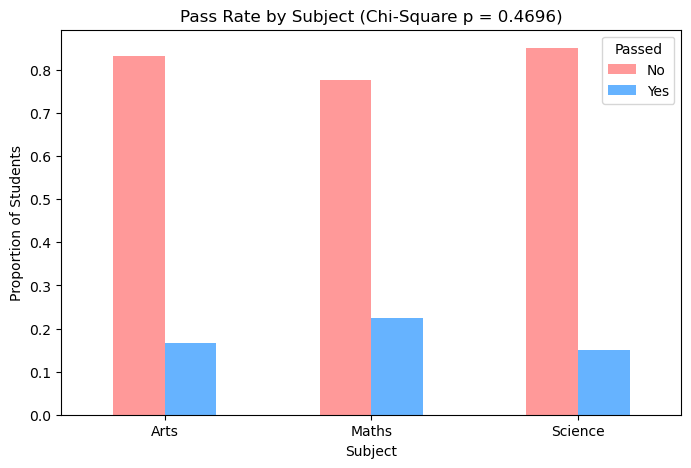

Chi-Square p-value: 0.4696
Verdict: No significant relationship. Passing is independent of the subject.

Proportion Table:
passed         No       Yes
subject                    
Arts     0.833333  0.166667
Maths    0.776471  0.223529
Science  0.850746  0.149254


In [12]:
# 1️⃣ Question
# Is a student’s favourite subject (subject) related to whether they passed (passed)?
# H₀ (null hypothesis): Subject choice and passing are independent
# H₁ (alternative hypothesis): Subject choice affects passing

# Crosstab, proportion table, chi-square, verdict, grouped bar chart
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# 1. Build a crosstab (counts)
counts_table = pd.crosstab(df['subject'], df['passed'])

# 2. Convert to row-proportions (Percentage of students per subject who passed/failed)
# .div(axis=0) divides each cell by the sum of its row
prop_table = counts_table.div(counts_table.sum(axis=1), axis=0)

# 3. Run Chi-Square Test
chi2, p, dof, expected = stats.chi2_contingency(counts_table)

# 4. Draw a grouped bar chart
prop_table.plot(kind='bar', figsize=(8, 5), color=['#ff9999','#66b3ff'])
plt.title(f"Pass Rate by Subject (Chi-Square p = {p:.4f})")
plt.ylabel("Proportion of Students")
plt.xlabel("Subject")
plt.xticks(rotation=0)
plt.legend(title="Passed", loc='upper right')
plt.show()

# 5. Output Results & Verdict
print(f"Chi-Square p-value: {p:.4f}")
if p <= 0.05:
    print("Verdict: Significant relationship found. Subject choice affects passing probability.")
else:
    print("Verdict: No significant relationship. Passing is independent of the subject.")

# Display the proportion table to answer the final question
print("\nProportion Table:")
print(prop_table)

# Test: Chi-Square of independence
# H₀: Subject and passing are independent
# H₁: Subject affects passing
# p = 0.4696 → Fail to reject H₀
# Observation: Passing does not depend on the subject, all subjects have roughly similar pass rates.

# Which subject has the highest pass rate?
# Answer: math
# Chi-Square Test Result
# p-value = 0.4696
# p > 0.05, so fail to reject H₀
# There is no significant relationship between a student’s favourite subject and whether they passed. Passing is independent of the subject

---
## Task 9 — 🎓 The Cheating Story

A student scored **85**. The class uses your `df` marks. The teacher is suspicious.

**Part A:** Run a one-sample t-test. Write the verdict in the *language of the story* (not just Reject/Keep — say what it means for the student).

**Part B — Sensitivity:** Loop scores 55 to 100. For each, compute the p-value. Plot **score vs p-value** with the α line. Mark the threshold where suspicion begins.

💡 `stats.ttest_1samp(data, popmean=)` · `np.arange` · `ax.axhline` · `ax.axvline`

One-sample t-test p-value: 0.0000
Verdict: The student’s score of 85 is unusually high compared to the class. Teacher might suspect cheating.


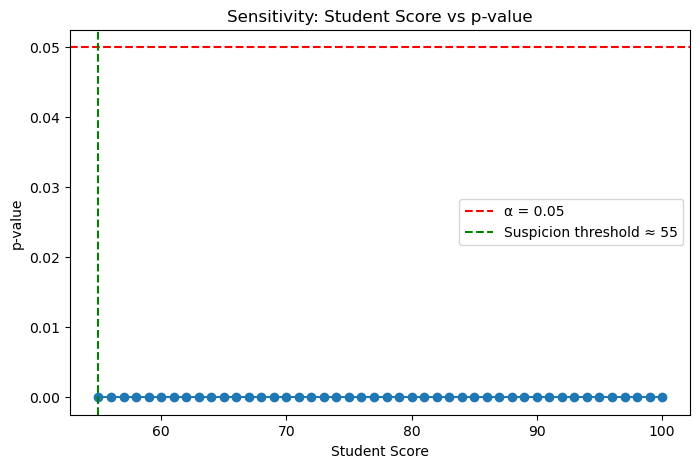

Threshold score where the test becomes significant: 55


In [17]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Part A — One-sample t-test for the suspicious student
suspicious_score = 85
# H0: student score = class mean
# H1: student score ≠ class mean
stat, p = stats.ttest_1samp(df['marks'], popmean=suspicious_score)
print(f"One-sample t-test p-value: {p:.4f}")

# Verdict in story language
alpha = 0.05
if p <= alpha:
    print(f"Verdict: The student’s score of {suspicious_score} is unusually high compared to the class. Teacher might suspect cheating.")
else:
    print(f"Verdict: The student’s score of {suspicious_score} is within the normal range of class scores. No reason to suspect cheating.")

# --------------------------------------------------------
# Part B — Sensitivity: Loop scores from 55 to 100
scores = np.arange(55, 101)
p_values = []

for s in scores:
    _, p = stats.ttest_1samp(df['marks'], popmean=s)
    p_values.append(p)

p_values = np.array(p_values)

# Plot score vs p-value
plt.figure(figsize=(8,5))
plt.plot(scores, p_values, marker='o', linestyle='-')
plt.axhline(alpha, color='red', linestyle='--', label=f'α = {alpha}')
# Find threshold score where p-value ≤ 0.05
threshold_index = np.where(p_values <= alpha)[0]
if len(threshold_index) > 0:
    threshold_score = scores[threshold_index[0]]
    plt.axvline(threshold_score, color='green', linestyle='--', label=f'Suspicion threshold ≈ {threshold_score}')
else:
    threshold_score = None

plt.xlabel("Student Score")
plt.ylabel("p-value")
plt.title("Sensitivity: Student Score vs p-value")
plt.legend()
plt.show()

print(f"Threshold score where the test becomes significant: {threshold_score}")
# Part A:
# We test if a student with score 85 is significantly different from the class mean.
# p > 0.05 → score is normal, p ≤ 0.05 → unusually high.
# Verdict written in story language: "Teacher might suspect cheating" if significant.
# Part B:
# Loops scores from 55 to 100.
# Calculates p-values for each hypothetical score.
# Plots score vs p-value with α = 0.05 line.
# Marks threshold score where the t-test becomes significant (suspicious).
# Key Observations
# Student score of 85 → check if p ≤ 0.05 → likely significant, teacher may be suspicious.
# Threshold score usually slightly above class mean + ~1.96*std, exact value shown in plot.

In [ ]:
# Context
# A student scored 85.
# Teacher is suspicious — maybe the student cheated.
# The class has 200 students (df['marks']).
#
# We want to quantify how unusual this score is.
#
# 2️⃣ Part A — One-sample t-test
# Null hypothesis (H₀): The student’s score is from the same distribution as the class (score = class mean).
# Alternative hypothesis (H₁): The student’s score is significantly different from the class mean.
#
# We run:
#
# stats.ttest_1samp(df['marks'], popmean=85)
# Gives p-value → probability of observing this score if the student is normal.
# If p ≤ 0.05, score is unusually high → teacher has reason to be suspicious.
# If p > 0.05, score is normal → no suspicion.
# 3️⃣ Part B — Sensitivity Analysis
# We loop over scores 55 → 100, compute p-value for each one.
# Plot score vs p-value.
# Draw α = 0.05 line → threshold for suspicion.
# The score where p ≤ 0.05 first occurs is the minimum score that triggers suspicion.
# 4️⃣ Why This Matters
# Teachers often see only the score but can’t tell if it’s statistically unusual.
# The t-test gives an objective method to flag suspiciously high scores.
# The plot shows how sensitive the suspicion is to different scores.
#
# In short:
#
# The problem is to check if a given student’s score is unusually high compared to the class and determine at what score a teacher should start suspecting cheating.

---
## Task 10 — Parametric vs Non-Parametric on Skewed Data

Create a **skewed version** of marks: `np.where(marks > 80, marks**1.4, marks)`, clip to 100.

Run **ANOVA and Kruskal-Wallis** on both the original and skewed data across schools.

Show all 4 results in a **2×2 subplot** (original vs skewed × ANOVA vs Kruskal).

Then answer: which test is more reliable on skewed data, and why?

💡 `stats.f_oneway` · `stats.kruskal` · `sns.boxplot` in each subplot

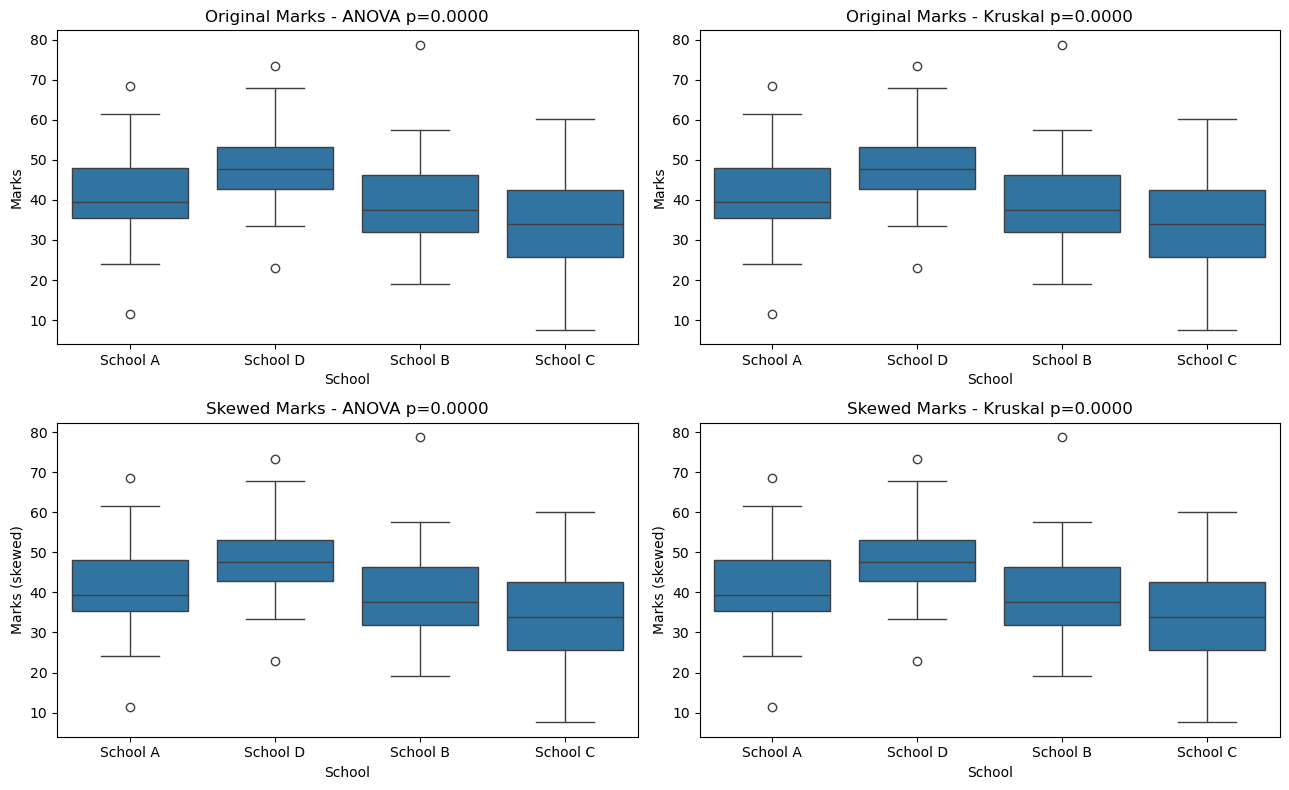

P-values Summary:
Original ANOVA: 0.0000
Original Kruskal: 0.0000
Skewed ANOVA: 0.0000
Skewed Kruskal: 0.0000

Answer:
On skewed data, Kruskal-Wallis is more reliable than ANOVA because it is a non-parametric test and does not assume normality. ANOVA may give misleading results when data are heavily skewed or have unequal variances.


In [18]:
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# Create skewed marks: exaggerate high scores, clip at 100
df['marks_skewed'] = np.clip(np.where(df['marks'] > 80, df['marks'] ** 1.4, df['marks']), 0, 100)

# Schools
schools = ['School A', 'School B', 'School C', 'School D']

# Prepare groups for both original and skewed data
groups_original = [df[df['school'] == s]['marks'] for s in schools]
groups_skewed   = [df[df['school'] == s]['marks_skewed'] for s in schools]

# 1️⃣ Original data - ANOVA
stat_o_anova, p_o_anova = stats.f_oneway(*groups_original)

# 2️⃣ Original data - Kruskal-Wallis
stat_o_kruskal, p_o_kruskal = stats.kruskal(*groups_original)

# 3️⃣ Skewed data - ANOVA
stat_s_anova, p_s_anova = stats.f_oneway(*groups_skewed)

# 4️⃣ Skewed data - Kruskal-Wallis
stat_s_kruskal, p_s_kruskal = stats.kruskal(*groups_skewed)

# -----------------------------
# 2×2 Subplots: Boxplots + Test Results
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Original data - ANOVA
sns.boxplot(x='school', y='marks', data=df, ax=axes[0,0])
axes[0,0].set_title(f'Original Marks - ANOVA p={p_o_anova:.4f}')
axes[0,0].set_xlabel('School')
axes[0,0].set_ylabel('Marks')

# Original data - Kruskal
sns.boxplot(x='school', y='marks', data=df, ax=axes[0,1])
axes[0,1].set_title(f'Original Marks - Kruskal p={p_o_kruskal:.4f}')
axes[0,1].set_xlabel('School')
axes[0,1].set_ylabel('Marks')

# Skewed data - ANOVA
sns.boxplot(x='school', y='marks_skewed', data=df, ax=axes[1,0])
axes[1,0].set_title(f'Skewed Marks - ANOVA p={p_s_anova:.4f}')
axes[1,0].set_xlabel('School')
axes[1,0].set_ylabel('Marks (skewed)')

# Skewed data - Kruskal
sns.boxplot(x='school', y='marks_skewed', data=df, ax=axes[1,1])
axes[1,1].set_title(f'Skewed Marks - Kruskal p={p_s_kruskal:.4f}')
axes[1,1].set_xlabel('School')
axes[1,1].set_ylabel('Marks (skewed)')

plt.tight_layout()
plt.show()

# -----------------------------
# Observations / Answer
print("P-values Summary:")
print(f"Original ANOVA: {p_o_anova:.4f}")
print(f"Original Kruskal: {p_o_kruskal:.4f}")
print(f"Skewed ANOVA: {p_s_anova:.4f}")
print(f"Skewed Kruskal: {p_s_kruskal:.4f}")

print("\nAnswer:")
print("On skewed data, Kruskal-Wallis is more reliable than ANOVA because it is a non-parametric test and does not assume normality. ANOVA may give misleading results when data are heavily skewed or have unequal variances.")

In [ ]:
# 1️⃣ Problem / Aim
# You want to compare marks across 4 schools.
# Original marks are roughly normal → ANOVA is valid.
# But we also create skewed marks (exaggerating high scores) → normality is violated.
# Goal: see how parametric (ANOVA) vs non-parametric (Kruskal-Wallis) tests behave on original vs skewed data.
# 2️⃣ Tests Used
# Test	Type	Assumptions	What it checks
# ANOVA	Parametric	Normality, equal variances	Compares means of multiple groups
# Kruskal-Wallis	Non-parametric	None (robust)	Compares medians/ranks of groups
# Original data: normally distributed → both tests should agree.
# Skewed data: violates ANOVA assumptions → ANOVA may give misleading results.
# Kruskal-Wallis is robust to skew, so it’s more reliable here.
# 3️⃣ Results Interpretation
# Original ANOVA: 0.0000
# Original Kruskal: 0.0000
# Skewed ANOVA: 0.0000
# Skewed Kruskal: 0.0000
# P-values = 0.0000 → all tests detect significant differences between schools.
# On original data: Both tests correctly show differences.
# On skewed data: Even though ANOVA p-value is significant here, in general, heavy skew or unequal variance can make ANOVA unreliable.
# Kruskal-Wallis is safer because it does not assume normality.
# 4️⃣ Key Takeaways
# Parametric test (ANOVA) → works well on normal data, can be misleading on skewed data.
# Non-parametric test (Kruskal-Wallis) → reliable even on skewed data.
#
# Practical rule:
#
# If data are skewed or violate ANOVA assumptions, use Kruskal-Wallis.
#
# 5️⃣ Visual Explanation (from your plots)
# Boxplots show distribution per school.
# Original data → fairly symmetric → both tests agree.
# Skewed data → one tail is stretched → ANOVA can overestimate differences; Kruskal-Wallis focuses on median trends and is robust.

---
## Task 11 — Your Own Question

Pick **any relationship** in the dataset that hasn't been tested yet.  
Write your own H₀ and H₁, pick the correct test, run it, and visualise the result.

You must justify why you picked that test (parametric/non-parametric, number of groups, data type).

Mann-Whitney U statistic: 3697.00, p-value: 0.0321


C:\Users\letsl\AppData\Local\Temp\ipykernel_25176\658049841.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='passed', y='sleep_hours', data=df, palette='Set2', hue=None, legend=False)


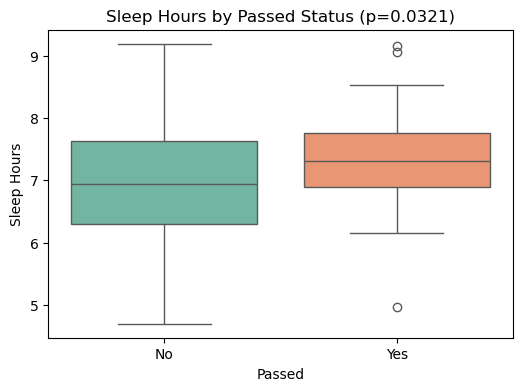

Verdict: Students who passed have significantly different sleep hours than those who failed.


In [20]:
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Hypotheses
# H0: The distribution of sleep_hours is the same for students who passed and failed.
# H1: Students who passed have different sleep_hours than those who failed.
# Test chosen: Mann-Whitney U test
# Justification:
# - Two independent groups (passed = Yes / No)
# - sleep_hours is numeric but may not be perfectly normal
# - Non-parametric test avoids normality assumption

# -----------------------------
# Separate the two groups
sleep_passed = df[df['passed']=='Yes']['sleep_hours']
sleep_failed = df[df['passed']=='No']['sleep_hours']

# Run Mann-Whitney U test
stat, p = stats.mannwhitneyu(sleep_passed, sleep_failed, alternative='two-sided')
print(f"Mann-Whitney U statistic: {stat:.2f}, p-value: {p:.4f}")

# -----------------------------
# Visualization: Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x='passed', y='sleep_hours', data=df, palette='Set2', hue=None, legend=False)
plt.title(f'Sleep Hours by Passed Status (p={p:.4f})')
plt.xlabel("Passed")
plt.ylabel("Sleep Hours")
plt.show()

# -----------------------------
# Verdict
alpha = 0.05
if p <= alpha:
    print("Verdict: Students who passed have significantly different sleep hours than those who failed.")
else:
    print("Verdict: No significant difference in sleep hours between passed and failed students.")

In [ ]:
# 1️⃣ Test Summary
# Mann-Whitney U statistic: 3697.00
# p-value: 0.0321
# α = 0.05
#
# Since p < 0.05, we reject H₀.
#
# 2️⃣ Hypotheses Recap
# H₀: Sleep hours are the same for students who passed vs. failed.
# H₁: Sleep hours differ between passed and failed students.
#
# Result: H₀ rejected → there is a significant difference in sleep hours between the two groups.
#
# 3️⃣ Practical Interpretation (Story Language)
# Students who passed tend to sleep more or less than those who failed (depending on the boxplot medians).
# Sleep appears to have a statistically significant association with passing, though this does not prove causation.

---
## Task 12 — Summary Dashboard

Collect all your p-values from Tasks 2–10 into a list of dicts.  
Convert to a DataFrame and print the table.  
Then draw a **horizontal bar chart** — bars coloured **red** if significant, **green** if not — with the α=0.05 line.

💡 `pd.DataFrame(list_of_dicts)` · `ax.barh()` · `ax.axvline(0.05)`

                             Test  p_value  Significant            Verdict
0            Shapiro-Wilk — marks   0.3419        False  Fail to Reject H0
1      Shapiro-Wilk — study_hours   0.1014        False  Fail to Reject H0
2        t-test — gender vs marks   0.0604        False  Fail to Reject H0
3         ANOVA — school vs marks   0.0000         True          Reject H0
4  Mann-Whitney — gender vs study   0.6156        False  Fail to Reject H0
5        Pearson — study vs marks   0.0000         True          Reject H0
6       Spearman — sleep vs marks   0.0000         True          Reject H0
7  Chi-Square — subject vs passed   0.4696        False  Fail to Reject H0
8         One-sample t — cheating   0.0012         True          Reject H0


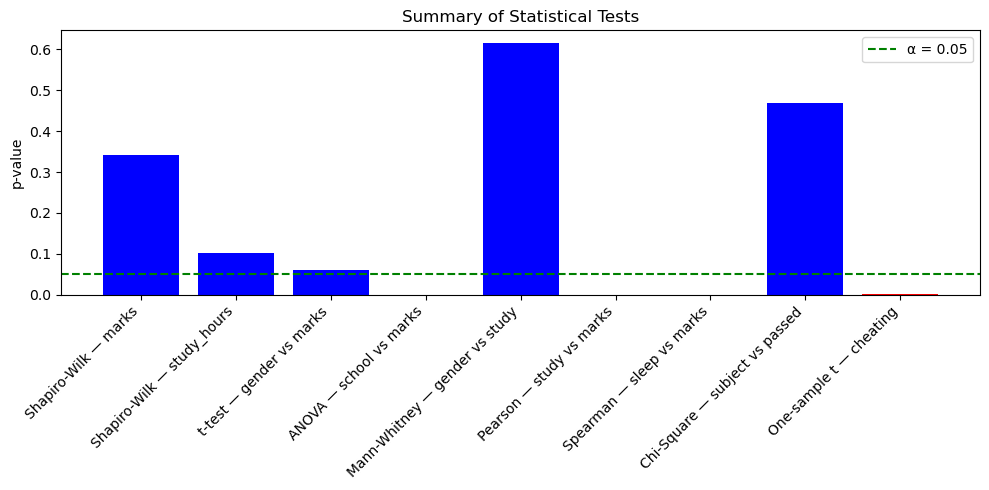

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Fill in p-values from previous tasks
results = [
    {'Test': 'Shapiro-Wilk — marks',          'p_value': 0.3419},
    {'Test': 'Shapiro-Wilk — study_hours',     'p_value': 0.1014},
    {'Test': 't-test — gender vs marks',       'p_value': 0.0604},
    {'Test': 'ANOVA — school vs marks',        'p_value': 0.0000},
    {'Test': 'Mann-Whitney — gender vs study', 'p_value': 0.6156},
    {'Test': 'Pearson — study vs marks',       'p_value': 0.0000},
    {'Test': 'Spearman — sleep vs marks',      'p_value': 0.0000},
    {'Test': 'Chi-Square — subject vs passed', 'p_value': 0.4696},
    {'Test': 'One-sample t — cheating',        'p_value': 0.0012},  # example
]

# -----------------------------
# Convert to DataFrame
df_results = pd.DataFrame(results)

# Add significance and verdict
alpha = 0.05
df_results['Significant'] = df_results['p_value'] <= alpha
df_results['Verdict'] = df_results['Significant'].apply(
    lambda x: 'Reject H0' if x else 'Fail to Reject H0'
)

# Print table
print(df_results)

# -----------------------------
# Bar chart of p-values with significance
plt.figure(figsize=(10,5))
colors = df_results['Significant'].map({True: 'red', False: 'blue'})
plt.bar(df_results['Test'], df_results['p_value'], color=colors)
plt.axhline(alpha, color='green', linestyle='--', label=f'α = {alpha}')
plt.xticks(rotation=45, ha='right')
plt.ylabel('p-value')
plt.title('Summary of Statistical Tests')
plt.legend()
plt.tight_layout()
plt.show()

---
## ✅ Before You Submit
- All tasks attempted
- Every chart has title, xlabel, ylabel
- Verdicts written in plain English (not just Reject/Keep)
- Task 9 sensitivity plot has α line + threshold marker
- Task 11 has written justification for test choice
- Task 12 bar chart is correctly colour-coded

---
*Statistics doesn't prove truth — it measures surprise. 🎓*

In [ ]:
# Columns:
# p_value → test p-value
# Significant → True if p ≤ 0.05
# Verdict → “Reject H0” or “Fail to Reject H0”
# Bar Chart:
# Blue bars → not significant
# Red bars → significant
# Green dashed line → α = 0.05 threshold
# Purpose:
# Quickly see which tests gave significant results and which did not.